In [1]:
from functions import *

from minerva.transforms.transform import *
from minerva.transforms.random_transform import *

from minerva.data.readers import TiffReader

from minerva.data.datasets import SimpleDataset

from minerva.data.data_modules import MinervaDataModule

from minerva.models.ssl.byol import BYOL
from minerva.models.nets.image.deeplabv3 import DeepLabV3Backbone

from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from lightning.pytorch.loggers.csv_logs import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer
from pathlib import Path

from functions import *


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
from lightning.fabric import seed_everything
seed_everything(32)

Seed set to 32


32

# Variables

## Paths

In [2]:
data_path = '/workspaces/shared_data/seismic/f3_segmentation/images'
annotation_path = '/workspaces/shared_data/seismic/f3_segmentation/annotations'
pretrain_logs_path =  '/workspaces/Seismic-Byol/dev-seismic-byol/logs/train'
pretrain_ckpt_path = '/workspaces/Seismic-Byol/dev-seismic-byol/ckpt/train'

## Hyperparameters

In [3]:
x = 256
input_size = (x, x)

dataset_name = 'seam_ai'

learning_rate = 0.1
batch_size = 32
num_epochs = 20

single_channel = True
accelerator = 'gpu'

model_name = f'teste'

## Transforms

In [4]:
# if dataset_name == 's0' or dataset_name == 'a700':

# aux_transform_pipeline = TransformPipeline([

#     random_flip,
#     random_rotation,
#     transpose_to_CHW,
# ])
# constrastive_transform = ContrastiveTransform(
#     aux_transform_pipeline
# )

# byol_transform_pipeline = TransformPipeline(
#     [
#         transpose_to_HWC,
#         repeat,
#         random_crop,
#         constrastive_transform,
#     ]
# )
    
# else: 

# aux_transform_pipeline = TransformPipeline(
#     [   
#         random_flip,
#         random_rotation,
#         transpose_to_CHW,
#         cast_to_tensor,
#         ]
# ) 

# constrastive_transform = ContrastiveTransform(
#     aux_transform_pipeline
# )

# byol_transform_pipeline = TransformPipeline(
#     [
#         random_crop,
#         constrastive_transform,
#     ]
# )

In [4]:
random_flip = RandomFlip(possible_axis=1)
random_crop = RandomCrop(crop_size=input_size)
random_rotation = RandomRotation(degrees=25, prob=0.9)
transpose = Transpose([2, 0, 1])
cast_to_tensor = CastTo(dtype=np.float32)

aux_transform_pipeline = TransformPipeline(
    [   
        # random_crop,
        random_flip,
        random_rotation,
        transpose,
        cast_to_tensor,
        ]
) 

constrastive_transform = ContrastiveTransform(
    aux_transform_pipeline
)

byol_transform_pipeline = TransformPipeline(
    [
        random_crop,
        constrastive_transform,
    ]
)

## Data Visualization

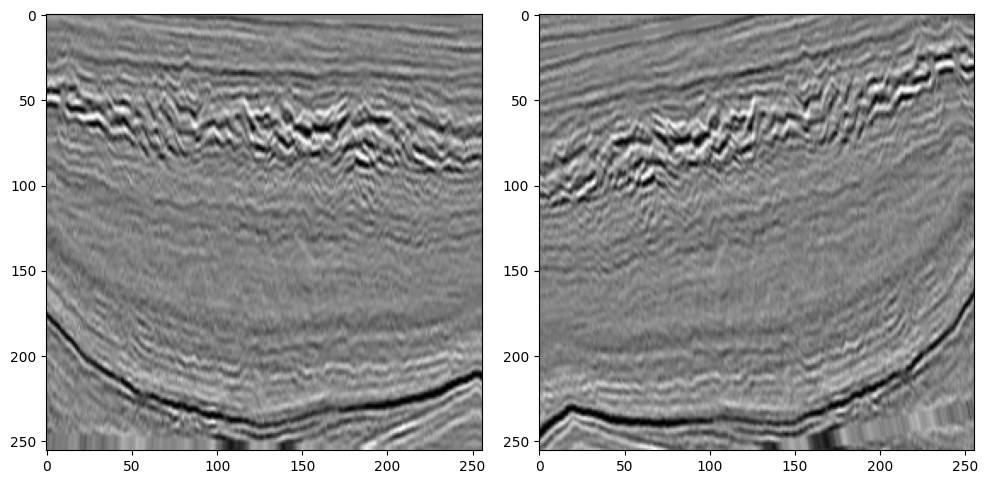

In [5]:
tiff_reader = TiffReader(path = data_path)
image_example = tiff_reader[0]
test_image = byol_transform_pipeline(image_example)

image_list = [
    test_image[0][0],
    test_image[1][0]

]
plot_images(image_list)

In [6]:
tiff_reader = TiffReader(path = data_path)
image_example = tiff_reader[0]

cropped_image = random_crop(image_example)
flipped_image = random_flip(cropped_image)
rotated_image = random_rotation(flipped_image)
final_image = byol_transform_pipeline(image_example)

In [7]:
image_example.shape, cropped_image.shape

((255, 701, 3), (256, 256, 3))

# Dataset

## Readers

In [8]:
train_img_reader_01 = TiffReader(path=data_path)
train_img_reader_02 = TiffReader(path=data_path)


pretrain_dataset = SimpleDataset(
    readers=train_img_reader_01,
    transforms=byol_transform_pipeline,
    return_single=True
)

In [11]:
subset_dataset = BinaryTreeSubset(pretrain_dataset, 1)

# DataModule

In [10]:
data_module = MinervaDataModule(
    train_dataset=pretrain_dataset,
    batch_size=batch_size,
    drop_last=True,
    shuffle_train=True,
    name=dataset_name
)

In [ ]:
Testing Data Module

data_module.setup("fit")
(train_batch_x, train_batch_y) = next(iter(data_module.train_dataloader()))
train_batch_y = next(iter(data_module.train_dataloader()))
train_batch_x.shape, train_batch_y.shape
len(train_batch_y)

# Model

In [12]:
backbone = DeepLabV3Backbone(
    num_classes=6
)

model = BYOL(
    backbone=backbone,
    learning_rate=learning_rate,
)


# Pipeline

## Trainer

In [13]:
log_dir = Path(pretrain_logs_path) / model_name / dataset_name
ckpt_dir = Path(pretrain_ckpt_path) / model_name / dataset_name
logger = CSVLogger(log_dir, name=model_name, version=dataset_name)
ckpt_callback = ModelCheckpoint(save_top_k=1, save_last=True, dirpath=ckpt_dir)

trainer = Trainer(
    accelerator='gpu', 
    logger=logger,
    callbacks=ckpt_callback,
    max_epochs=num_epochs,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [14]:
pipeline = SimpleLightningPipeline(
    model=model,
    trainer=trainer,
    log_dir=log_dir,
    save_run_status=True,
)

In [15]:
pipeline.run(data_module, task='fit')

/home/vscode/.local/lib/python3.10/site-packages/lightning/fabric/utilities/seed.py:42: No seed found, seed set to 0
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                     | Params | Mode 
------------------------------------------------------------------------------
0 | backbone                 | DeepLabV3Backbone        | 25.6 M | train
1 | projection_head          | Sequential               | 9.4 M  | train
2 | prediction_head          | MLP                      | 2.1 M  | train
3 | backbone_momentum        | DeepLabV3Backbone        | 25.6 M | train
4 | projection_head_momentum | Sequential               | 9.4 M  | train
5 | criterion                | NegativeCosineSimilarity | 0      | train
------------------------------------------------------------------------------
37.1 M    Trainable params
35.0 M    Non-trainable params
72.1 M    Total params
288.493   Total estimated model params size (MB)
329       Modules in train mode
0        

** Seed set to: 0 **
Pipeline info saved at: /workspaces/Seismic-Byol/dev-seismic-byol/logs/train/teste/seam_ai/run_2025-05-14-15-03-43eecfda10.yaml
Epoch 0:  48%|████▊     | 22/46 [00:08<00:09,  2.55it/s, v_num=m_ai]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:
from functions import *

In [ ]:
model = get_model(
    "sup",
    0.001,
    False,
    0,
    None
)

2025-05-13 14:04:34 - minerva - INFO - No model loaded!
